## Teste A/B para Campanha de Marketing
 Utilizando o conjunto de dados disponibilizado na plataforma Kaggle, será realizada uma análise comparativa 
 entre os grupos do experimento. O objetivo é avaliar a eficácia dos anúncios, estimar o potencial de receita 
 e verificar se as diferenças observadas entre os grupos são estatisticamente significativas.

 Neste notebook, aplicaremos técnicas de Análise Exploratória de Dados (EDA) e testes de hipóteses em A/B testing, 
 utilizando Python para explorar, analisar e interpretar os resultados do experimento.

### Principais Objetivos
 1. Carregar e explorar o conjunto de dados
 2. Limpar e tratar os dados
 3. Comparar o desempenho dos grupos do experimento (EDA)
 4. Aplicar testes estatísticos para validar o experimento
 5. Estimar o impacto da campanha no negócio
 6. Gerar conclusões e recomendações

### Pergunta de Negócio
 A campanha tradicional ("ad") gera mais conversões do que a campanha alternativa ("psa")?


### 1 - Importação das Bibliotecas
Nesta etapa, são importadas as bibliotecas responsáveis pela manipulação, análise e validação de experimento de Teste A/B.

Inclui ferramentas para tratamento dos dados (Pandas, NumPy), visualização das diferenças entre grupos (Matplotlib, Seaborn) e testes estatísticos para comparação de proporções e significância (SciPy, Statsmodels).
Também permite carregar o dataset do Kaggle e preparar o ambiente para a análise experimental.

In [2]:
# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Estatística
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Configuração visual
sns.set(style="whitegrid")

# Base de dados Kaggle
import kagglehub

# Ocultar avisos saida
import warnings
warnings.filterwarnings('ignore')  # ignora warnings

### 2 - Carregamento do Conjunto de Dados

Nesta etapa, carregamos o dataset Marketing A/B Testing e o estruturamos em um DataFrame do Pandas para análise. 

O conjunto de dados contém informações sobre usuários, incluindo grupo de teste, conversões e número de anúncios visualizados. Esses dados permitem comparar o desempenho entre os grupos e avaliar o impacto da campanha, com o objetivo de identificar se houve aumento significativo nas conversões.

In [3]:
# Download dataset
path = kagglehub.dataset_download("faviovaz/marketing-ab-testing")

# Carregar arquivo
df = pd.read_csv(path + "/marketing_AB.csv")
df.head()


,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


### 3 - Análise Exploratória de Dados (EDA)
Nesta etapa, exploramos o dataset para analisar a distribuição dos dados e identificar diferenças iniciais entre os grupos A e B. Essa exploração permite detectar padrões e garantir que o teste de hipótese seja aplicado de forma adequada.


#### Distribuição dos Grupos
O dataset possui 588.101 registros e 7 colunas, sem valores nulos, contendo informações sobre usuários, grupo de teste, conversão e visualização de anúncios.

As variáveis incluem IDs, grupo de teste (ad ou psa), conversão (True/False) e métricas de anúncios visualizados.

A distribuição dos grupos é desbalanceada, com cerca de 96% no grupo “ad” e 4% no grupo “psa”.

In [4]:
df.info()
df.describe()
df.isnull().sum()

#DISTRIBUIÇÃO DOS GRUPOS
df['test group'].value_counts()
df['test group'].value_counts(normalize=True) * 100
## FORTE DESBALANCEAMENTO !!

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Unnamed: 0     588101 non-null  int64 
 1   user id        588101 non-null  int64 
 2   test group     588101 non-null  object
 3   converted      588101 non-null  bool  
 4   total ads      588101 non-null  int64 
 5   most ads day   588101 non-null  object
 6   most ads hour  588101 non-null  int64 
dtypes: bool(1), int64(4), object(2)
memory usage: 27.5+ MB


test group
ad     96.000007
psa     3.999993
Name: proportion, dtype: float64

#### Taxa de conversão por grupo (A/B)
O grupo que recebeu anúncios (ad) apresentou uma taxa de conversão mais alta (~2,6%) em comparação ao grupo psa (~1,8%). Isso indica que a exibição de anúncios pode estar associada a um aumento na probabilidade de compra.



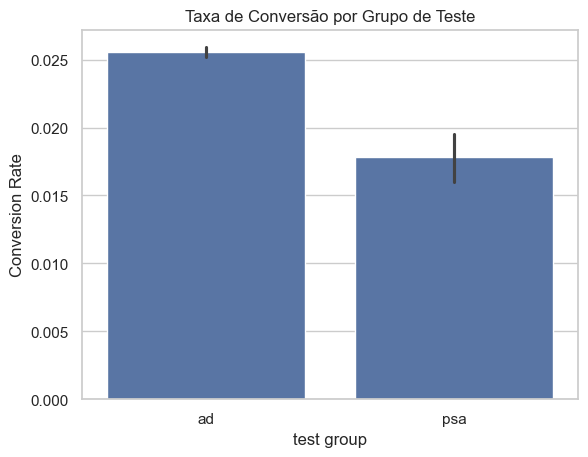

In [5]:
conversion_by_group = df.groupby('test group')['converted'].mean()
sns.barplot(x='test group', y='converted', data=df)
plt.title("Taxa de Conversão por Grupo de Teste")
plt.ylabel("Conversion Rate")
plt.show()

#### Estatísticas de anúncios visualizados por grupo
O grupo “ad” possui muito mais usuários e gerou 14.423 conversões, enquanto o grupo “psa” teve 420. A média de anúncios visualizados é praticamente igual entre os dois grupos (cerca de 24). Porém, a taxa de conversão é maior no grupo “ad” (≈2,55%) do que no “psa” (≈1,79%), indicando melhor desempenho do anúncio.

In [6]:
summary = df.groupby('test group').agg(
    usuarios=('user id','count'),
    media_ads=('total ads','mean'),
    conversoes=('converted','sum'),
    taxa_conversao=('converted','mean'))
print(summary)

            usuarios  media_ads  conversoes  taxa_conversao
test group                                                 
ad            564577  24.823365       14423        0.025547
psa            23524  24.761138         420        0.017854


#### Intervalo de Confiança - 95%
Calculando o IC da taxa de conversão para cada grupo do teste A/B

Seus resultados

Grupo ad
IC: 0.02513 – 0.02596
≈ 2.51% a 2.60%

Grupo psa
IC: 0.01616 – 0.01955
≈ 1.62% a 1.95%

O intervalo de confiança de 95% mostra que a taxa de conversão do grupo ad (~2.5%) é superior à do grupo psa (~1.7%). Como os intervalos não se sobrepõem, isso reforça a evidência de diferença significativa entre os grupos.


In [7]:

def confidence_interval(group):
    data = df[df['test group'] == group]['converted']
    mean = data.mean()
    std = data.std()
    n = len(data)
    margin = 1.96 * (std / np.sqrt(n))
    return mean - margin, mean + margin

ci_ad = confidence_interval('ad')
ci_psa = confidence_interval('psa')

print("IC ad:", ci_ad)
print("IC psa:", ci_psa)

IC ad: (np.float64(0.025134991615561292), np.float64(0.025958127657806203))
IC psa: (np.float64(0.01616184765106538), np.float64(0.019546365237899082))


### 4 - Teste de Hipótese
Após a exploração dos dados, realizamos o teste de hipóteses para avaliar os resultados do teste A/B utilizando Statsmodels e SciPy.

H0 (hipótese nula): as taxas de conversão são iguais.

Se p ≤ 0,05, rejeitamos H0 e concluímos que há diferença significativa entre as taxas.

H1 (hipótese alternativa): as taxas de conversão são diferentes.

Se p > 0,05, não rejeitamos H0, indicando que não há evidência suficiente de diferença.

#### Suposições Estatísticas
Antes de aplicar testes comparativos, avaliamos se os grupos A (ad) e B (psa) apresentam distribuição e variâncias compatíveis:

Teste de normalidade (Shapiro-Wilk)
Grupo ad: estatística = 0.1463, p < 0.001
Grupo psa: estatística = 0.1179, p < 0.001

→ p < 0.05 indica que os dados não seguem distribuição normal.

Homogeneidade de variância (Levene)
Estatística = 54.3229, p < 0.001
→ p < 0.05 indica que as variâncias entre os grupos são diferentes.

Conclusão:
Os dados não são normais e apresentam variâncias heterogêneas. Portanto, não é adequado usar testes paramétricos; recomenda-se aplicar um teste de proporção (Z-test) para comparar as taxas de conversão entre os grupos ad e psa.

In [8]:
import pandas as pd
from scipy import stats

# separar grupos
ad = df[df['test group'] == 'ad']
psa = df[df['test group'] == 'psa']

# transformar booleano em 0 e 1
ad_conv = ad['converted'].astype(int)
psa_conv = psa['converted'].astype(int)

# -------------------------
# 1. Teste de normalidade
# -------------------------
shapiro_ad = stats.shapiro(ad_conv.sample(5000))
shapiro_psa = stats.shapiro(psa_conv.sample(5000))

print("Shapiro AD:", shapiro_ad)
print("Shapiro PSA:", shapiro_psa)

# -------------------------
# 2. Homogeneidade variância
# -------------------------
levene = stats.levene(ad_conv, psa_conv)

print("Levene:", levene)

Shapiro AD: ShapiroResult(statistic=np.float64(0.14861576951222222), pvalue=np.float64(4.432429134324703e-92))
Shapiro PSA: ShapiroResult(statistic=np.float64(0.109944614876342), pvalue=np.float64(4.099650124831876e-93))
Levene: LeveneResult(statistic=np.float64(54.322884225785735), pvalue=np.float64(1.703305262783129e-13))


#### Teste Z para Proporções

O teste Z de proporções comparou as taxas de conversão entre os grupos ad e psa.

Resultado:
Estatística Z = 7.37
p-valor = 1.70e-13

Interpretação:
Como o p-valor é muito menor que 0.05, rejeitamos a hipótese nula (H₀) de que as taxas de conversão são iguais ou seja existe diferença estatisticamente significativa entre os grupos ad e psa, indicando que a exposição aos anúncios impactou a taxa de conversão.

In [9]:
conversions = df.groupby('test group')['converted'].sum()
n = df.groupby('test group')['converted'].count()

stat, p_value = proportions_ztest(conversions, n)

print("Estatística Z:", stat)
print("p-valor:", p_value)
#Rejeitamos H0: As taxas são diferentes

Estatística Z: 7.3700781265454145
p-valor: 1.7052807161559727e-13


#### Teste Qui-Quadrado
Esse teste é utilizado para verificar se existe associação entre variáveis categóricas, comparando as frequências observadas com as frequências esperadas.

Qui-quadrado = 54.01
p-valor = 1.99e-13

Interpretação:
Como o p-valor é muito menor que 0.05, rejeitamos a hipótese nula de independência. Isso indica que existe associação estatisticamente significativa entre o grupo do teste (ad ou psa) e a conversão, sugerindo que o tipo de exposição pode influenciar o comportamento de conversão dos usuários.

In [10]:
contingency = pd.crosstab(df['test group'], df['converted'])

chi2, p, dof, expected = stats.chi2_contingency(contingency)

print("Qui-quadrado:", chi2)
print("p-valor:", p)
#Rejeitamos H0: grupo influencia conversão.

Qui-quadrado: 54.005823883685245
p-valor: 1.9989623063390075e-13


#### Tamanho do Efeito - Cohen'sd
Foi calculado o tamanho do efeito utilizando Cohen's d para medir a magnitude da diferença entre os grupos.
O resultado foi d = 0.0528, indicando um efeito muito pequeno.
Isso sugere que, embora exista diferença estatisticamente significativa entre as taxas de conversão,
o impacto prático da diferença é baixo.

In [11]:
group_ad = df[df['test group'] == 'ad']['converted']
group_psa = df[df['test group'] == 'psa']['converted']

mean_diff = group_ad.mean() - group_psa.mean()
pooled_std = np.sqrt((group_ad.std()**2 + group_psa.std()**2) / 2)

cohens_d = mean_diff / pooled_std

print("Cohen's d:", cohens_d)

Cohen's d: 0.05281326756420405


#### Regressão Logistica
Foi aplicada regressão logística para avaliar o efeito do grupo experimental na conversão. O resultado mostrou que o grupo ad possui odds 1.44 vezes maiores de conversão em relação ao grupo psa (p < 0.001), indicando que a exposição ao anúncio aumenta significativamente a probabilidade de conversão

Interpretação do resultado

coef = 0.366 → estar no grupo ad aumenta o log da probabilidade de conversão.

p-value < 0.001 → efeito estatisticamente significativo.

exp(coef) = 1.44 → usuários no grupo ad têm ~44% mais chance de converter que no grupo psa.

In [12]:
df['group_encoded'] = df['test group'].map({'ad': 1, 'psa': 0})

X = sm.add_constant(df['group_encoded'])
y = df['converted']

model = sm.Logit(y, X).fit()
print(model.summary())


np.exp(model.params)

Optimization terminated successfully.
         Current function value: 0.117730
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:              converted   No. Observations:               588101
Model:                          Logit   Df Residuals:                   588099
Method:                           MLE   Df Model:                            1
Date:                Mon, 09 Mar 2026   Pseudo R-squ.:               0.0004342
Time:                        10:40:58   Log-Likelihood:                -69237.
converged:                       True   LL-Null:                       -69267.
Covariance Type:            nonrobust   LLR p-value:                 8.800e-15
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -4.0075      0.049    -81.393      0.000      -4.104      -3.911
group_encoded     0.

const            0.018179
group_encoded    1.442146
dtype: float64

### 5 - Resumo e Conclusão

#### Resumo do projeto
Análise de um experimento de A/B testing em campanhas de marketing, comparando a taxa de conversão entre os grupos ad e psa. O objetivo foi verificar se a diferença observada é estatisticamente significativa e avaliar seu impacto.

#### Passos realizados:

Carregamento e exploração inicial do dataset.

Análise exploratória para comparar distribuição e conversões entre os grupos.

Cálculo da taxa de conversão por grupo.

Teste de Pressuponto : normalidade (Shapiro-Wilk) e homogeneidade de variâncias (Levene).

Teste de Hipótese: Teste Z para comparação de proporções e  Teste Qui-quadrado.

Cálculo do tamanho do efeito (Cohen’s d).

#### Conclusão:
O grupo ad apresentou taxa de conversão significativamente maior que o grupo psa (p < 0.05).
Apesar da significância estatística, o tamanho do efeito é pequeno, indicando impacto prático limitado.

#### Próximos Passos:

Avaliar o impacto financeiro da diferença de conversão.

Testar novas variações de campanhas e criativos.

Analisar segmentos de usuários com maior probabilidade de conversão.